In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from epymodelingsuite.multistrain.formatter import (
    compute_quantiles,
    add_state_abbreviations,
    compute_rate_trend_categories,
    compute_rate_trend_pmf,
    create_flusight_submission,
    RATE_TREND_CATEGORIES,
)
from epymodelingsuite.multistrain.aggregator import pull_single_strain_submission
from epymodelingsuite.schema.output import (
    get_flusight_quantiles,
    get_flusight_horizons,
    get_flusight_categorical_horizons,
)
from epymodelingsuite.utils.location import convert_location_name_format


## Configuration

Set timespan configs:

In [2]:
SUBMISSION_WEEK = "202614"
REFERENCE_DATE = "2026-04-11"
WINDOW = "202550-202613"

Choose augmentation and baseline:

In [3]:
AUGMENTED = True
BASELINE = True
BASELINE_k = 5

These configs are unlikely to need changing:

In [4]:
DIST_FUNC = "wrmse"
STRAINS = "h1-h3-b"
TARGET = "hosp_aug" if AUGMENTED else "hosp"
TARGET_LONG = "flu_hosp_25"
SUFFIX = "_augmented" if AUGMENTED else ""

Derived config values:

In [5]:
REFERENCE_DT = pd.to_datetime(REFERENCE_DATE)
final_date = REFERENCE_DT + pd.Timedelta(weeks=4)
final_date

Timestamp('2026-05-09 00:00:00')

## Data

In [6]:
# Load single-strain submission file
single_source_location = f"gs://gs_mobs_jessica/pipeline/flu/{SUBMISSION_WEEK}/{TARGET}_smc_{DIST_FUNC}_{WINDOW}/*/outputs/*"
single_fname = f"output_hub_formatted.csv.gz"
df_single = pull_single_strain_submission(source_location=single_source_location, fname=single_fname)
df_single.head()

Copying gs://gs_mobs_jessica/pipeline/flu/202614/hosp_aug_smc_wrmse_202550-202613/20260408-183047-ab2eb9e5/outputs/20260408-203013/output_hub_formatted.csv.gz to file:///tmp/tmp2w8kbx_k/output_hub_formatted.csv.gz
  


Downloaded: output_hub_formatted.csv.gz


.


,location,reference_date,horizon,target_end_date,target,output_type,output_type_id,value
0,US,2026-04-11,-1,2026-04-04,wk inc flu hosp,quantile,0.01,308.0
1,US,2026-04-11,0,2026-04-11,wk inc flu hosp,quantile,0.01,283.0
2,US,2026-04-11,1,2026-04-18,wk inc flu hosp,quantile,0.01,296.0
3,US,2026-04-11,2,2026-04-25,wk inc flu hosp,quantile,0.01,257.0
4,US,2026-04-11,3,2026-05-02,wk inc flu hosp,quantile,0.01,261.0


In [7]:
# Load ground truth hospital data
hospital_data = pd.read_csv(f"../flu-forecast-epydemix/common-data/surveillance/{TARGET_LONG}_{SUBMISSION_WEEK}_prelim{SUFFIX}.csv")
hospital_data['abbreviation'] = hospital_data['location_iso'].apply(lambda key: key.split("-")[-1])
hospital_data['date'] = pd.to_datetime(hospital_data['target_end_date'])

# Compute quantiles for both sampling methods
random_combined = pd.read_csv(f"../experiments/multistrain/{SUBMISSION_WEEK}-{TARGET}/multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}/trajectories_aggregated.csv")
if BASELINE:
    baselines_avg = pd.read_csv("baselines_2025.csv")
    random_combined = random_combined.merge(baselines_avg, left_on = "location", right_on="epydemix_population")
    p_values = BASELINE_k / (BASELINE_k + random_combined['baseline'])
    random_combined['baseline_sample'] = np.random.negative_binomial(BASELINE_k, p_values)
    random_combined['target_total'] = random_combined['target_total'] + random_combined['baseline_sample']
random_quantiles = compute_quantiles(random_combined)

# Add abbreviations
random_quantiles = add_state_abbreviations(random_quantiles)
random_quantiles['date'] = pd.to_datetime(random_quantiles['date'])

# Get sorted list of populations (US first, then states alphabetically)
populations = sorted(random_quantiles['location'].unique())
populations = ['United_States'] + [p for p in populations if p != 'United_States']

print(f"Plotting {len(populations)} locations")

Plotting 52 locations


In [8]:
print(f"Quantiles shape: {random_quantiles.shape}")
print(f"Quantile columns: {[c for c in random_quantiles.columns if c.startswith('q')]}")
random_quantiles.head(10)

Quantiles shape: (1820, 26)
Quantile columns: ['q010', 'q025', 'q050', 'q100', 'q150', 'q200', 'q250', 'q300', 'q350', 'q400', 'q450', 'q500', 'q550', 'q600', 'q650', 'q700', 'q750', 'q800', 'q850', 'q900', 'q950', 'q975', 'q990']


,location,date,q010,q025,q050,q100,q150,q200,q250,q300,...,q650,q700,q750,q800,q850,q900,q950,q975,q990,abbreviation
0,United_States,2025-09-20,232.87,294.975,343.75,452.9,512.85,584.6,633.00,689.7,...,1078.70,1143.3,1219.00,1323.0,1457.30,1693.0,1969.05,2155.050,2435.15,US
1,United_States,2025-09-27,245.62,305.975,388.95,484.4,563.85,645.8,699.00,747.7,...,1262.05,1371.3,1524.50,1717.4,2051.15,2453.2,3051.15,3580.825,4195.62,US
2,United_States,2025-10-04,290.87,348.000,445.85,527.6,605.70,694.8,758.00,822.1,...,1536.00,1733.6,2024.50,2304.8,2648.90,3012.4,3694.05,4075.175,4781.07,US
3,United_States,2025-10-11,299.00,364.000,461.90,594.1,666.00,744.0,805.75,886.7,...,1902.80,2138.1,2389.50,2730.4,2976.45,3366.1,4186.45,4912.375,6030.00,US
4,United_States,2025-10-18,303.78,400.925,483.00,621.4,709.00,817.8,945.75,1073.1,...,2242.40,2434.6,2721.00,3002.2,3302.10,3809.7,4884.65,5605.175,6430.88,US
5,United_States,2025-10-25,323.93,412.975,508.90,699.4,832.95,991.2,1162.00,1312.2,...,2570.35,2791.3,3026.50,3365.0,3743.45,4155.1,5235.25,6015.875,7246.49,US
6,United_States,2025-11-01,342.92,464.800,582.75,825.9,1050.10,1263.2,1447.75,1678.7,...,3038.50,3237.0,3480.25,3742.6,4019.15,4821.7,6017.10,6961.175,8029.37,US
7,United_States,2025-11-08,455.61,644.775,844.80,1117.8,1453.25,1731.2,2050.75,2241.7,...,3637.75,3919.4,4236.75,4613.4,4907.40,5666.3,6737.25,8433.275,9496.73,US
8,United_States,2025-11-15,520.92,809.100,1125.70,1647.9,2031.25,2307.2,2574.75,2780.1,...,4374.95,4661.9,4950.00,5271.2,5813.90,6520.1,7728.05,9897.225,11095.73,US
9,United_States,2025-11-22,897.96,1452.950,1742.00,2315.4,2729.25,3118.0,3424.75,3697.7,...,5342.10,5648.0,6015.50,6540.2,7089.20,8058.1,9782.65,11801.650,13174.92,US


## Plot

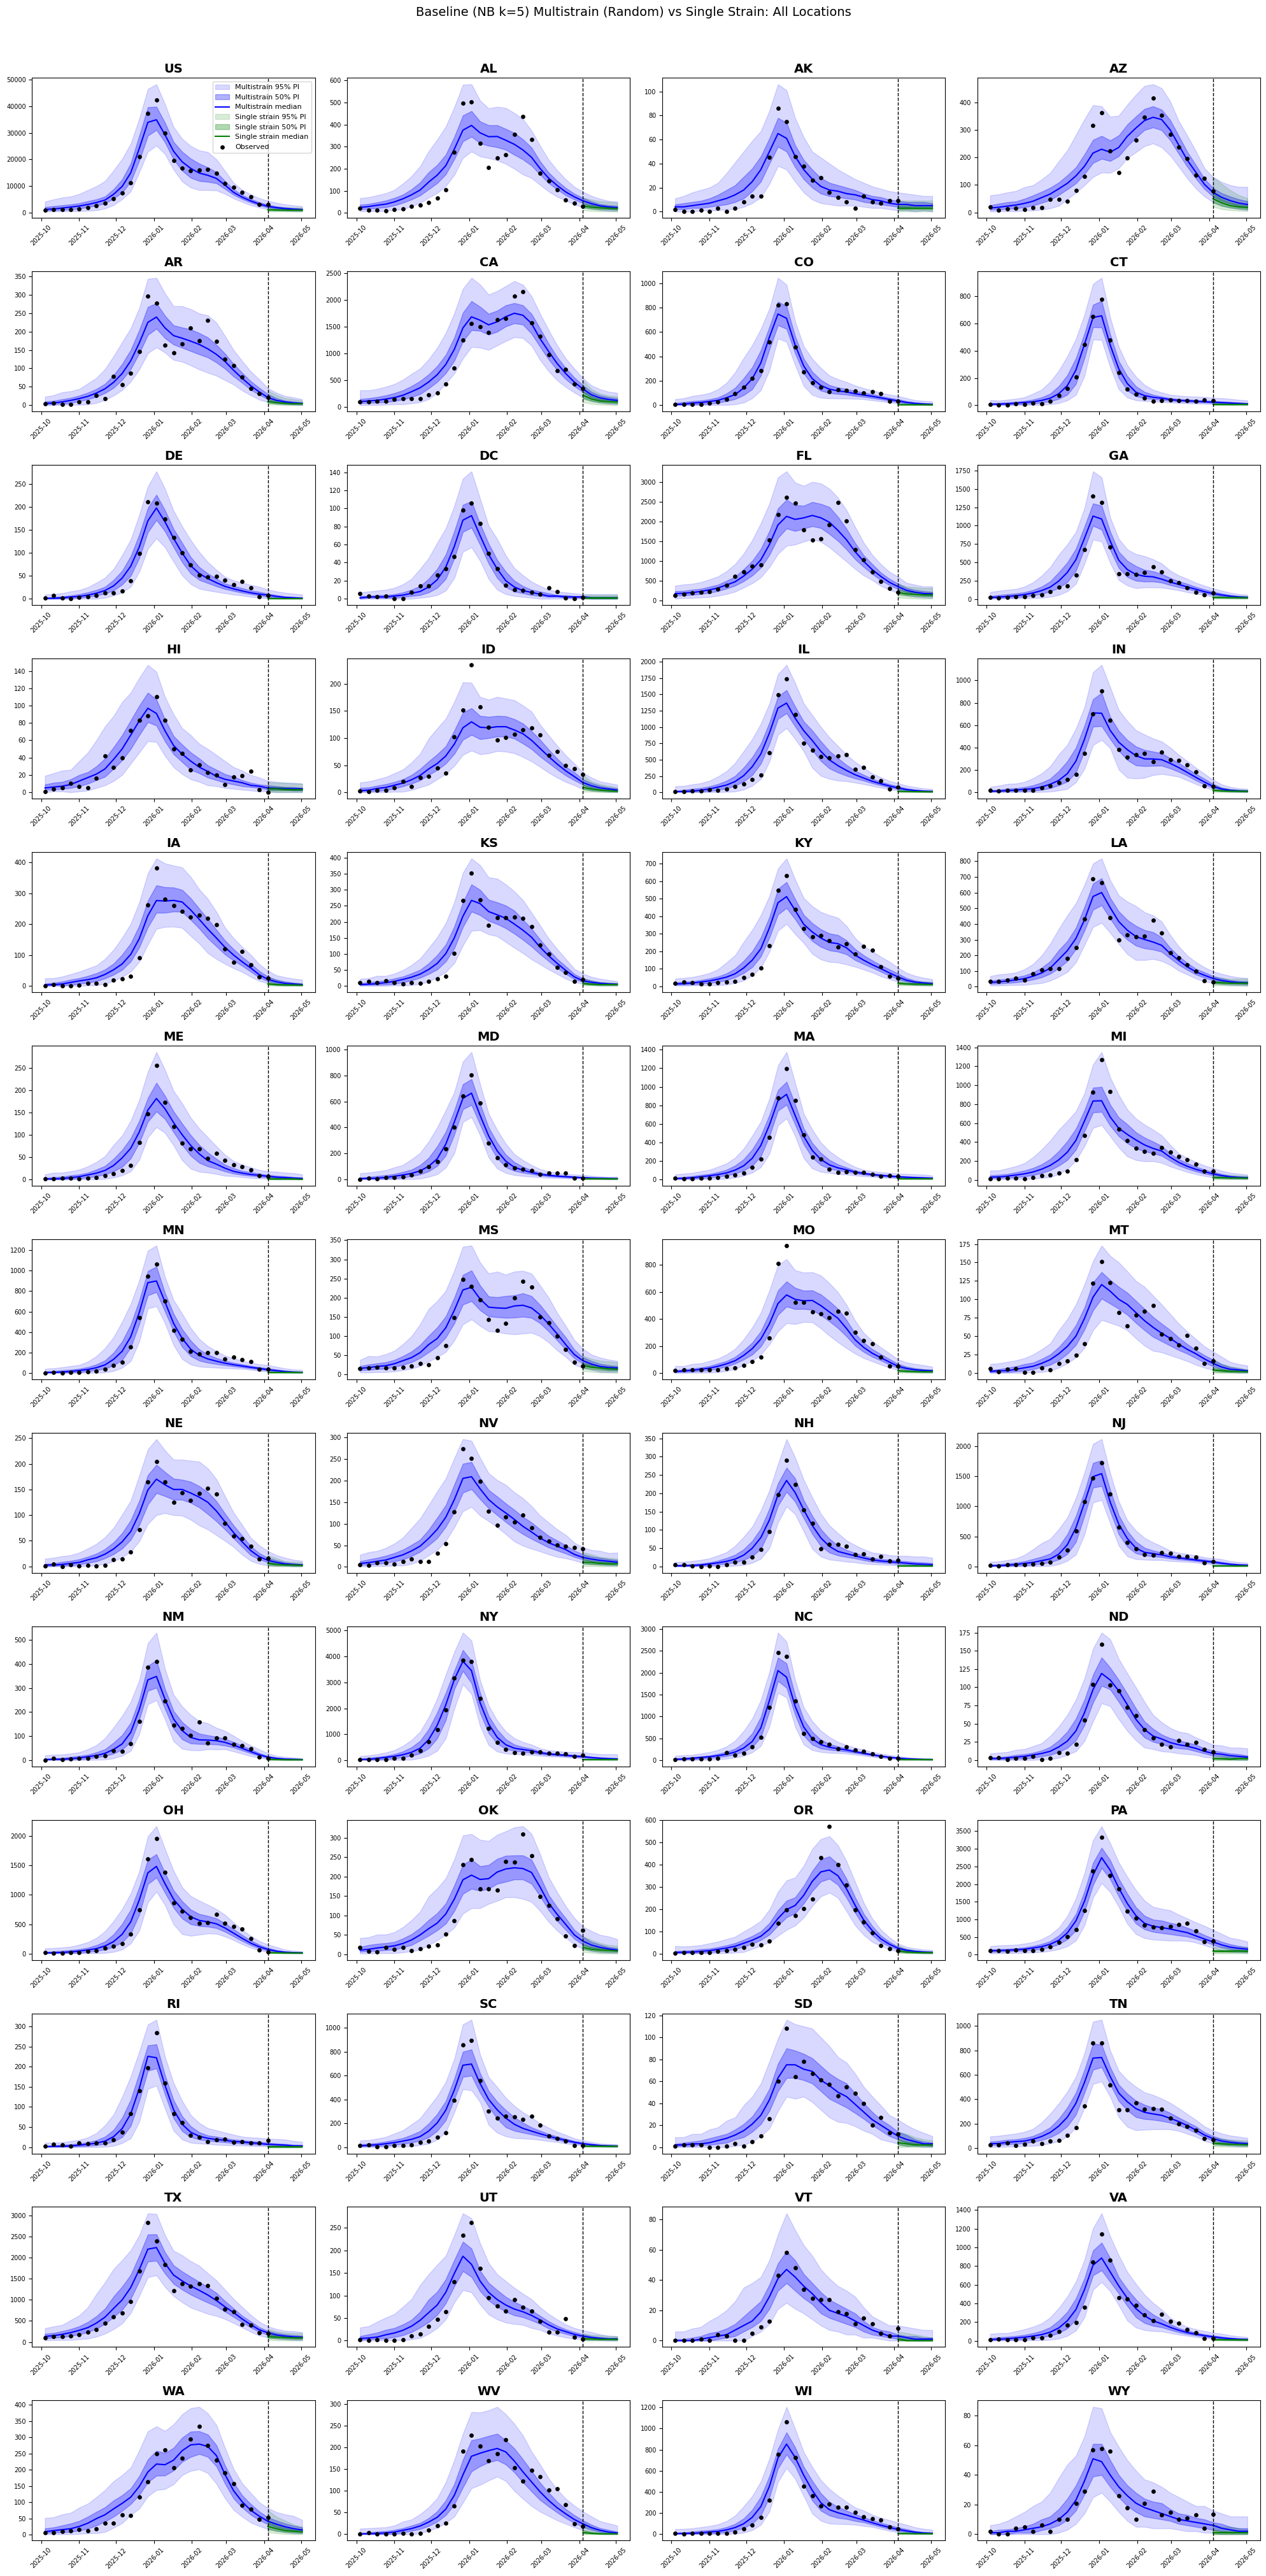

In [17]:
FILTER_PLOT = False
FILTER_PLOT_START = '2026-02-01'
LONG_PLOT_START = '2025-10-01'

if FILTER_PLOT:
    plot_start_date = pd.to_datetime(FILTER_PLOT_START)
    plot_prefix = 'filtered_'
    if BASELINE:
        plot_prefix = 'filtered_baseline_'
else:
    plot_start_date = pd.to_datetime(LONG_PLOT_START)
    plot_prefix = ''
    if BASELINE:
        plot_prefix = 'baseline_'

random_quantiles_filter =random_quantiles[(random_quantiles['date'] >= plot_start_date) & (random_quantiles['date'] < final_date)]

hospital_data_filter = hospital_data[(hospital_data['date'] >= plot_start_date) & (hospital_data['date'] < final_date)]


# Convert df_single to wide format for plotting (matching random_quantiles format)
df_single_quantiles = df_single[df_single['output_type'] == 'quantile'].copy()
df_single_quantiles['target_end_date'] = pd.to_datetime(df_single_quantiles['target_end_date'])

# Pivot to get quantile columns
df_single_wide = df_single_quantiles.pivot_table(
    index=['location', 'target_end_date'],
    columns='output_type_id',
    values='value'
).reset_index()

# Rename columns to match random_quantiles format
df_single_wide.columns.name = None
df_single_wide = df_single_wide.rename(columns={
    'target_end_date': 'date',
    '0.025': 'q025', '0.25': 'q250', '0.5': 'q500', '0.75': 'q750', '0.975': 'q975'
})

# Filter to date range
df_single_filter = df_single_wide[
    (df_single_wide['date'] >= plot_start_date) & 
    (df_single_wide['date'] < final_date)
]

# Create 13x4 comparison figure: Random multistrain vs Single strain
fig, axes = plt.subplots(13, 4, figsize=(20, 40))
axes = axes.flatten()

for idx, pop in enumerate(populations):
    ax = axes[idx]
    abbrev = convert_location_name_format(value=pop, output_format="abbreviation", input_format="epydemix_population", location_type="iso")
    location_code = convert_location_name_format(value=abbrev, output_format="FIPS", input_format="abbreviation", location_type="iso")
    
    # Get data for this population
    rand_pop = random_quantiles_filter[random_quantiles_filter['location'] == pop].sort_values('date')
    single_pop = df_single_filter[df_single_filter['location'] == location_code].sort_values('date')
    hosp_pop = hospital_data_filter[hospital_data_filter['abbreviation'] == abbrev].sort_values('date')
    
    # Plot random multistrain sampling (blue)
    ax.fill_between(rand_pop['date'], rand_pop['q025'], rand_pop['q975'], 
                    alpha=0.15, color='blue', label='Multistrain 95% PI')
    ax.fill_between(rand_pop['date'], rand_pop['q250'], rand_pop['q750'], 
                    alpha=0.3, color='blue', label='Multistrain 50% PI')
    ax.plot(rand_pop['date'], rand_pop['q500'], 'b-', linewidth=1.5, label='Multistrain median')
    
    # Plot single strain (green)
    ax.fill_between(single_pop['date'], single_pop['q025'], single_pop['q975'], 
                    alpha=0.15, color='green', label='Single strain 95% PI')
    ax.fill_between(single_pop['date'], single_pop['q250'], single_pop['q750'], 
                    alpha=0.3, color='green', label='Single strain 50% PI')
    ax.plot(single_pop['date'], single_pop['q500'], 'g-', linewidth=1.5, label='Single strain median')
    
    # Plot ground truth (black markers)
    ax.scatter(hosp_pop['date'], hosp_pop['hospitalizations'], 
               color='black', s=15, zorder=5, label='Observed')
    
    ax.set_title(abbrev, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.axvline(REFERENCE_DT - pd.Timedelta(weeks=1), color='black', linestyle='--', linewidth=1)
    
    # Only show legend for first subplot
    if idx == 0:
        ax.legend(fontsize=8, loc='upper right')

# Hide any unused subplots
for idx in range(len(populations), len(axes)):
    axes[idx].set_visible(False)
    

if BASELINE:
    title = f'Baseline (NB k={BASELINE_k}) Multistrain (Random) vs Single Strain: All Locations'
else:
    title = 'Multistrain (Random) vs Single Strain: All Locations'
plt.suptitle(title, fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'../experiments/multistrain/{SUBMISSION_WEEK}-{TARGET}/multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}/{plot_prefix}multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}_multistrain_vs_single_comparison.pdf', 
            dpi=150, bbox_inches='tight')
plt.show()

## Submission File

In [10]:
# Compute rate trend categories for each trajectory
# Baseline comes from surveillance data, target from trajectories
categories_df = compute_rate_trend_categories(
    df=random_combined,
    reference_date=REFERENCE_DATE,
    surveillance_df=hospital_data,
    horizons=get_flusight_categorical_horizons(),
    value_col='target_total',
    surveillance_date_col='date',
    surveillance_value_col='hospitalizations',
    surveillance_location_col='abbreviation'
)

print(f"Categories computed: {len(categories_df):,} rows")
print(f"Unique populations: {categories_df['population'].nunique()}")
print(f"Horizons: {sorted(categories_df['horizon'].unique())}")
print(f"\nCategory distribution:")
print(categories_df['category'].value_counts())
print(f"\nBaseline values come from surveillance (same for all samples per location):")
categories_df.tail(10)



Categories computed: 208,000 rows
Unique populations: 52
Horizons: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Category distribution:
category
stable            156459
decrease           46428
increase            4512
large_decrease       555
large_increase        46
Name: count, dtype: int64

Baseline values come from surveillance (same for all samples per location):


,reference_date,sample_id,population,abbreviation,baseline_date,horizon,target_date,baseline_value,target_value,count_change,rate_change,category
207990,2026-04-11,240,United_States_Wyoming,WY,2026-04-04,3,2026-05-02,13.333333,0.0,-13.333333,-2.269048,decrease
207991,2026-04-11,221,United_States_Wyoming,WY,2026-04-04,3,2026-05-02,13.333333,2.0,-11.333333,-1.928691,decrease
207992,2026-04-11,961,United_States_Wyoming,WY,2026-04-04,3,2026-05-02,13.333333,8.0,-5.333333,-0.907619,stable
207993,2026-04-11,339,United_States_Wyoming,WY,2026-04-04,3,2026-05-02,13.333333,3.0,-10.333333,-1.758512,decrease
207994,2026-04-11,419,United_States_Wyoming,WY,2026-04-04,3,2026-05-02,13.333333,2.0,-11.333333,-1.928691,decrease
207995,2026-04-11,847,United_States_Wyoming,WY,2026-04-04,3,2026-05-02,13.333333,1.0,-12.333333,-2.098869,decrease
207996,2026-04-11,179,United_States_Wyoming,WY,2026-04-04,3,2026-05-02,13.333333,2.0,-11.333333,-1.928691,decrease
207997,2026-04-11,465,United_States_Wyoming,WY,2026-04-04,3,2026-05-02,13.333333,2.0,-11.333333,-1.928691,decrease
207998,2026-04-11,516,United_States_Wyoming,WY,2026-04-04,3,2026-05-02,13.333333,2.0,-11.333333,-1.928691,decrease
207999,2026-04-11,529,United_States_Wyoming,WY,2026-04-04,3,2026-05-02,13.333333,0.0,-13.333333,-2.269048,decrease


In [11]:
# Compute PMF from categories
pmf_df = compute_rate_trend_pmf(categories_df)

print(f"PMF shape: {pmf_df.shape}")
print(f"Columns: {pmf_df.columns.tolist()}")
print(f"\nProbabilities sum to 1: {(pmf_df[RATE_TREND_CATEGORIES].sum(axis=1).round(6) == 1).all()}")
#pmf_df.head(20)

PMF shape: (208, 9)
Columns: ['population', 'abbreviation', 'horizon', 'target_date', 'large_decrease', 'decrease', 'stable', 'increase', 'large_increase']

Probabilities sum to 1: True


In [12]:
# Format PMF for hub submission (long format)
pmf_long = pmf_df.melt(
    id_vars=['population', 'abbreviation', 'horizon', 'target_date'],
    value_vars=RATE_TREND_CATEGORIES,
    var_name='output_type_id',
    value_name='value'
)

# Add required columns for FluSight format
pmf_long['target'] = 'wk flu hosp rate change'
pmf_long['output_type'] = 'pmf'
pmf_long['location'] = pmf_long['abbreviation']

# Reorder columns
hub_pmf = pmf_long[[
    'location', 'target', 'horizon', 'target_date', 
    'output_type', 'output_type_id', 'value'
]]

print(f"Hub submission format shape: {hub_pmf.shape}")
print(f"\nSample rows:")
hub_pmf.head(15)

Hub submission format shape: (1040, 7)

Sample rows:


,location,target,horizon,target_date,output_type,output_type_id,value
0,US,wk flu hosp rate change,0,2026-04-11,pmf,large_decrease,0.0
1,US,wk flu hosp rate change,1,2026-04-18,pmf,large_decrease,0.0
2,US,wk flu hosp rate change,2,2026-04-25,pmf,large_decrease,0.0
3,US,wk flu hosp rate change,3,2026-05-02,pmf,large_decrease,0.0
4,AL,wk flu hosp rate change,0,2026-04-11,pmf,large_decrease,0.0
5,AL,wk flu hosp rate change,1,2026-04-18,pmf,large_decrease,0.0
6,AL,wk flu hosp rate change,2,2026-04-25,pmf,large_decrease,0.0
7,AL,wk flu hosp rate change,3,2026-05-02,pmf,large_decrease,0.0
8,AK,wk flu hosp rate change,0,2026-04-11,pmf,large_decrease,0.0
9,AK,wk flu hosp rate change,1,2026-04-18,pmf,large_decrease,0.0


In [13]:
# Export PMF for hub submission (uncomment to save)
# output_file = f"../data/multistrain-data/{SUBMISSION_WEEK}/rate_trend_pmf.csv"
# hub_pmf.to_csv(output_file, index=False)
# print(f"Saved PMF to: {output_file}")

# Verify probabilities sum to 1 for each location/horizon
verification = hub_pmf.groupby(['location', 'horizon'])['value'].sum()
print("All PMFs sum to 1:", (verification.round(6) == 1).all())
print(f"\nTotal PMF entries: {len(hub_pmf)}")
print(f"Locations: {hub_pmf['location'].nunique()}")
print(f"Horizons: {sorted(hub_pmf['horizon'].unique())}")
print(f"Categories per location/horizon: {len(RATE_TREND_CATEGORIES)}")

All PMFs sum to 1: True

Total PMF entries: 1040
Locations: 52
Horizons: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Categories per location/horizon: 5


In [14]:
# Create complete FluSight submission
submission = create_flusight_submission(
    trajectories_df=random_combined,
    pmf_df=pmf_df,
    reference_date=REFERENCE_DATE,
    horizons=get_flusight_horizons(),
    value_col='target_total'
)

print(f"Submission shape: {submission.shape}")
print(f"\nColumns: {submission.columns.tolist()}")
print(f"\nTargets: {submission['target'].unique()}")
print(f"Output types: {submission['output_type'].unique()}")
print(f"Horizons: {sorted(submission['horizon'].unique())}")
print(f"Locations: {submission['location'].nunique()}")
print(f"\nRows per target:")
print(submission.groupby(['target', 'output_type']).size())

Submission shape: (7020, 8)

Columns: ['reference_date', 'horizon', 'target_end_date', 'location', 'target', 'output_type', 'output_type_id', 'value']

Targets: <StringArray>
['wk flu hosp rate change', 'wk inc flu hosp']
Length: 2, dtype: str
Output types: <StringArray>
['pmf', 'quantile']
Length: 2, dtype: str
Horizons: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Locations: 52

Rows per target:
target                   output_type
wk flu hosp rate change  pmf            1040
wk inc flu hosp          quantile       5980
dtype: int64


In [15]:
submission

,reference_date,horizon,target_end_date,location,target,output_type,output_type_id,value
0,2026-04-11,0,2026-04-11,01,wk flu hosp rate change,pmf,decrease,0.012
1,2026-04-11,0,2026-04-11,01,wk flu hosp rate change,pmf,increase,0.374
2,2026-04-11,0,2026-04-11,01,wk flu hosp rate change,pmf,large_decrease,0.000
3,2026-04-11,0,2026-04-11,01,wk flu hosp rate change,pmf,large_increase,0.000
4,2026-04-11,0,2026-04-11,01,wk flu hosp rate change,pmf,stable,0.614
...,...,...,...,...,...,...,...,...
7015,2026-04-11,3,2026-05-02,US,wk inc flu hosp,quantile,0.85,1616.000
7016,2026-04-11,3,2026-05-02,US,wk inc flu hosp,quantile,0.9,1778.000
7017,2026-04-11,3,2026-05-02,US,wk inc flu hosp,quantile,0.95,2078.000
7018,2026-04-11,3,2026-05-02,US,wk inc flu hosp,quantile,0.975,2353.000


In [16]:
sub_prefix = "baseline_" if BASELINE else ""
submission.to_csv(f"../experiments/multistrain/{SUBMISSION_WEEK}-{TARGET}/multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}/{sub_prefix}{REFERENCE_DATE}-MOBS-EpyStrain_Flu.csv",
                  index=False)